In [1]:
import numpy as np
import pandas as pd
from pathlib import Path 
import os
import shutil

# Import spatialtissuepy
from spatialtissuepy import SpatialTissueData
from spatialtissuepy.io import (
    read_csv,
    write_csv,
    read_json,
    write_json
)

import matplotlib.pyplot as plt
from spatialtissuepy.viz import (
    set_publication_style, plot_spatial_scatter, 
    plot_ripleys_curve, save_figure
)

# Create a temporary directory for examples
import tempfile
temp_dir = tempfile.mkdtemp()
print(f"Working directory: {temp_dir}")

Working directory: /var/folders/99/8rc4_4_n7233rmjmy44dmfbs5531hj/T/tmpz722q4e3


In [2]:
# Create sample data
n_cells = 200

# Generate coordinates
x = np.random.uniform(0, 1000, n_cells)
y = np.random.uniform(0, 1000, n_cells)

# Generate cell types
cell_types = np.random.choice(
    ['CD8_T_cell', 'CD4_T_cell', 'Tumor', 'Macrophage'],
    size=n_cells,
    p=[0.25, 0.20, 0.35, 0.20]
)

# Generate marker data (simulating protein expression)
cd8_expression = np.random.lognormal(mean=2, sigma=1, size=n_cells)
pd1_expression = np.random.lognormal(mean=1.5, sigma=0.8, size=n_cells)
ki67_expression = np.random.uniform(0, 100, n_cells)  # Proliferation marker

# Create DataFrame
df = pd.DataFrame({
    'x': x,
    'y': y,
    'cell_type': cell_types,
    'CD8': cd8_expression,
    'PD1': pd1_expression,
    'Ki67': ki67_expression
})

# Save to CSV
csv_path = Path(temp_dir) / 'tissue_sample.csv'
df.to_csv(csv_path, index=False)

# Display first few rows
print("Sample CSV data:")
print(df.head(10))
print(f"\nSaved to: {csv_path}")

Sample CSV data:
            x           y   cell_type        CD8       PD1       Ki67
0  605.670296  894.276211       Tumor   3.847909  3.664288  72.983333
1  916.972721  762.543585  CD4_T_cell   7.582293  3.867855  76.063841
2  959.491755  783.512011       Tumor   2.284172  3.386975  82.277680
3  881.268893  783.363777       Tumor   9.661036  7.765877  41.667091
4  957.682045  370.261196       Tumor  14.401486  2.384131  78.798201
5   28.908332  896.422949  CD4_T_cell  12.198280  7.394174  94.694965
6  707.171282  730.693795  CD8_T_cell   2.504564  5.315284  18.113727
7  574.957229  249.108204  CD8_T_cell  18.176343  8.083354  55.582176
8  426.813251  427.142159       Tumor   7.725029  4.480717  12.289765
9  705.495373  895.730404       Tumor   2.929712  9.451386  33.941724

Saved to: /var/folders/99/8rc4_4_n7233rmjmy44dmfbs5531hj/T/tmpz722q4e3/tissue_sample.csv


In [3]:
# Load the CSV file
data = read_csv(
    csv_path,
    x_col='x',
    y_col='y',
    celltype_col='cell_type'
)

print(data)
print(f"\nCell types present: {data.cell_types_unique}")
print(f"Marker columns: {list(data.markers.columns) if data.markers is not None else 'None'}")

SpatialTissueData
  Cells: 200
  Dimensions: 2D
  Cell types: 4
  Markers: 3
  Bounds: x=[4.7, 998.5], y=[0.5, 993.1]

Cell types present: ['CD4_T_cell' 'CD8_T_cell' 'Macrophage' 'Tumor']
Marker columns: ['CD8', 'PD1', 'Ki67']


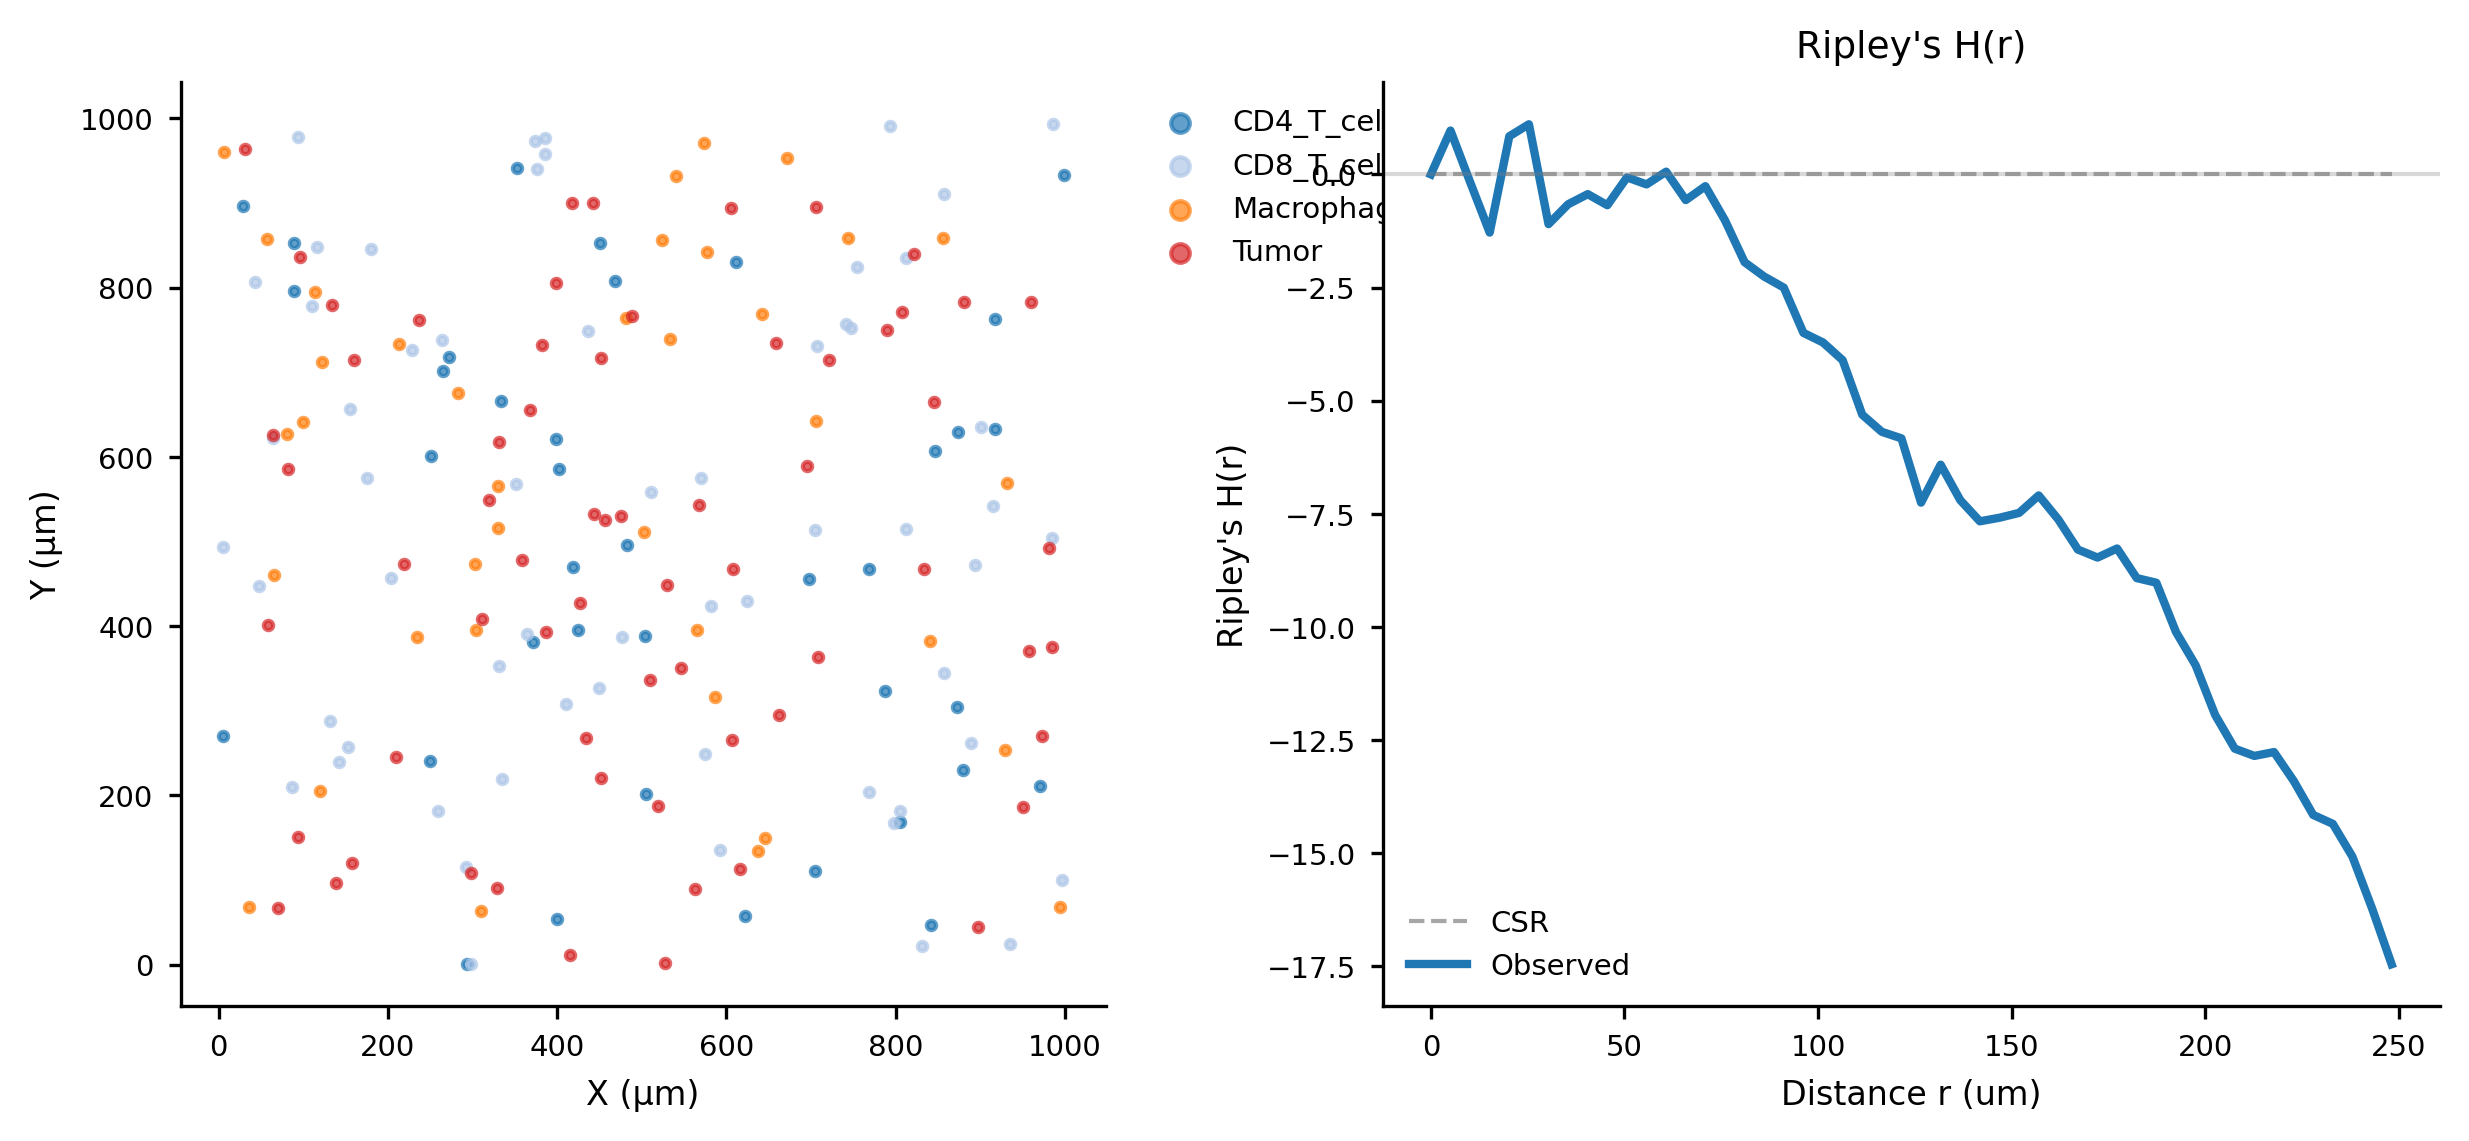

In [4]:
set_publication_style(journal='nature')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_spatial_scatter(data, ax=axes[0])
plot_ripleys_curve(data, ax=axes[1])

save_figure(fig, f'{temp_dir}/figure1', formats=['pdf', 'png'])

In [5]:
# Cleanup: Remove temporary files
shutil.rmtree(temp_dir)
print("Temporary files cleaned up.")

Temporary files cleaned up.
